# Section 1: BigQuery Connection
This notebook connects to Google BigQuery to analyze the Top Spotify Songs in Venezuela dataset.
The data was sourced from Kaggle and uploaded to the project: capstone-guillermo.

In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "capstone-guillermo"
client = bigquery.Client(project=PROJECT_ID)
print("Successfully connected to BigQuery!")

Successfully connected to BigQuery!


# Section 2: SQL Data Acquisition
We retrieve all records from the venezuela_top_songs table using SQL.
Additional queries filter and aggregate the data to explore trends.

In [2]:
# Query 1: Load full dataset
query = """
SELECT *
FROM `capstone-guillermo.spotify_data.venezuela_top_songs`
"""
df_full = client.query(query).to_dataframe()
print("Total rows:", len(df_full))

Total rows: 28263


In [3]:
# Query 2: Top 10 most frequent artists
query2 = """
SELECT artists, COUNT(*) as days_in_chart
FROM `capstone-guillermo.spotify_data.venezuela_top_songs`
GROUP BY artists
ORDER BY days_in_chart DESC
LIMIT 10
"""
df_top_artists = client.query(query2).to_dataframe()
print(df_top_artists)

           artists  days_in_chart
0        Bad Bunny           1837
1          KAROL G           1482
2             Feid            977
3            Beéle            873
4            Jimin            541
5  Feid, ATL Jacob            516
6  Alleh, Yorghaki            513
7      Myke Towers            436
8           Plan B            426
9  Bad Bunny, Feid            425


In [4]:
# Query 3: Songs that reached #1
query3 = """
SELECT name, artists, COUNT(*) as days_at_number_one
FROM `capstone-guillermo.spotify_data.venezuela_top_songs`
WHERE daily_rank = 1
GROUP BY name, artists
ORDER BY days_at_number_one DESC
LIMIT 10
"""
df_number_ones = client.query(query3).to_dataframe()
print(df_number_ones)

                            name                              artists  \
0                           LUNA                      Feid, ATL Jacob   
1          La Plena - W Sound 05     W Sound, Beéle, Ovy On The Drums   
2                            Who                                Jimin   
3                    PERRO NEGRO                      Bad Bunny, Feid   
4                          VeLDÁ        Bad Bunny, Omar Courtz, Dei V   
5   Si Antes Te Hubiera Conocido                              KAROL G   
6                          Santa  Rvssian, Rauw Alejandro, Ayra Starr   
7            capaz (merengueton)                      Alleh, Yorghaki   
8  Q U E V A S H A C E R H O Y ?              Omar Courtz, De La Rose   
9               no tiene sentido                                Beéle   

   days_at_number_one  
0                 136  
1                  73  
2                  66  
3                  54  
4                  39  
5                  31  
6                  30  
7   

In [5]:
# Query 3: Songs that reached #1
query3 = """
SELECT name, artists, COUNT(*) as days_at_number_one
FROM `capstone-guillermo.spotify_data.venezuela_top_songs`
WHERE daily_rank = 1
GROUP BY name, artists
ORDER BY days_at_number_one DESC
LIMIT 10
"""
df_number_ones = client.query(query3).to_dataframe()
print(df_number_ones)

                            name                              artists  \
0                           LUNA                      Feid, ATL Jacob   
1          La Plena - W Sound 05     W Sound, Beéle, Ovy On The Drums   
2                            Who                                Jimin   
3                    PERRO NEGRO                      Bad Bunny, Feid   
4                          VeLDÁ        Bad Bunny, Omar Courtz, Dei V   
5   Si Antes Te Hubiera Conocido                              KAROL G   
6                          Santa  Rvssian, Rauw Alejandro, Ayra Starr   
7            capaz (merengueton)                      Alleh, Yorghaki   
8  Q U E V A S H A C E R H O Y ?              Omar Courtz, De La Rose   
9               no tiene sentido                                Beéle   

   days_at_number_one  
0                 136  
1                  73  
2                  66  
3                  54  
4                  39  
5                  31  
6                  30  
7   

# Section 3: DataFrame Creation
We examine the structure of the dataset including shape, data types, and initial observations.

In [6]:
print("Shape:", df_full.shape)
print("\nData Types:\n", df_full.dtypes)
print("\nFirst 5 rows:")
df_full.head()

Shape: (28263, 25)

Data Types:
 spotify_id             object
name                   object
artists                object
daily_rank              Int64
daily_movement          Int64
weekly_movement         Int64
country                object
snapshot_date          dbdate
popularity              Int64
is_explicit           boolean
duration_ms             Int64
album_name             object
album_release_date     dbdate
danceability          float64
energy                float64
key                     Int64
loudness              float64
mode                    Int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          Int64
dtype: object

First 5 rows:


,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,7lyv2sysHCzFjypILxAynT,None,None,36,14,14,VE,2023-11-10,0,True,...,0,-4.643,1,0.0517,0.0232,0.000000,0.0699,0.533,90.019,4
1,7uKqnK0Fe6mWIDocv4YhOw,PODCAST,"Akapellah, Oldtape",49,1,1,VE,2024-05-01,50,True,...,0,-8.468,0,0.3170,0.2290,0.000000,0.0846,0.886,91.005,4
2,5MVCWWnNKaWnVMaCvj6TKU,RD,"Alejandro Armes, Soyneel, DJ Nelson",49,1,1,VE,2024-11-10,68,False,...,8,-8.933,1,0.3250,0.4370,0.000116,0.1110,0.271,104.885,4
3,5MVCWWnNKaWnVMaCvj6TKU,RD,"Alejandro Armes, Soyneel, DJ Nelson",43,5,-7,VE,2024-11-02,68,False,...,8,-8.933,1,0.3250,0.4370,0.000116,0.1110,0.271,104.885,4
4,5MVCWWnNKaWnVMaCvj6TKU,RD,"Alejandro Armes, Soyneel, DJ Nelson",48,-1,-8,VE,2024-11-01,68,False,...,8,-8.933,1,0.3250,0.4370,0.000116,0.1110,0.271,104.885,4


# Section 4: Data Quality Assessment
We check for missing values, duplicates, and any data issues.

In [7]:
# Missing values
print("Missing values per column:")
print(df_full.isnull().sum())

Missing values per column:
spotify_id            0
name                  1
artists               1
daily_rank            0
daily_movement        0
weekly_movement       0
country               0
snapshot_date         0
popularity            0
is_explicit           0
duration_ms           0
album_name            1
album_release_date    1
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
dtype: int64


In [8]:
# Duplicate rows
print("Duplicate rows:", df_full.duplicated().sum())

Duplicate rows: 0


In [9]:
# Check for songs with no name
print("Rows with missing song name:", df_full['name'].isnull().sum())
print("Rows with missing artist:", df_full['artists'].isnull().sum())

Rows with missing song name: 1
Rows with missing artist: 1


# Section 5: Data Preparation
We clean the data and create new useful columns for analysis.

In [10]:
import matplotlib.pyplot as plt

# Convert date column
df_full['snapshot_date'] = pd.to_datetime(df_full['snapshot_date'])

# Extract year and month
df_full['year'] = df_full['snapshot_date'].dt.year
df_full['month'] = df_full['snapshot_date'].dt.month

# Convert duration from ms to seconds
df_full['duration_sec'] = df_full['duration_ms'] / 1000

# Drop rows with missing song name or artist
df_clean = df_full.dropna(subset=['name', 'artists'])
print("Rows after cleaning:", len(df_clean))

Rows after cleaning: 28262


# Section 6: Exploratory Data Analysis
We analyze trends, patterns, and relationships within the Venezuela Spotify data.

In [11]:
# Descriptive statistics
df_clean[['daily_rank', 'popularity', 'danceability', 'energy', 'valence', 'tempo']].describe()

,daily_rank,popularity,danceability,energy,valence,tempo
count,28262.0,28262.0,28262.000000,28262.000000,28262.000000,28262.000000
mean,25.496108,81.400149,0.726504,0.667210,0.545610,115.947379
std,14.431264,12.660857,0.147158,0.151029,0.215368,27.282067
min,1.0,0.0,0.093900,0.000020,0.000010,53.376000
25%,13.0,78.0,0.668000,0.604000,0.399000,96.057000
50%,25.0,84.0,0.757000,0.687000,0.544000,105.011000
75%,38.0,88.0,0.833000,0.756000,0.697000,128.027000
max,50.0,100.0,0.957000,0.981000,0.992000,213.503000


In [12]:
# Top artists by days in chart
top_artists = df_clean['artists'].value_counts().head(10)
print(top_artists)

artists
Bad Bunny          1837
KAROL G            1482
Feid                977
Beéle               873
Jimin               541
Feid, ATL Jacob     516
Alleh, Yorghaki     513
Myke Towers         436
Plan B              426
Bad Bunny, Feid     425
Name: count, dtype: int64


In [13]:
# Average popularity by top artists
avg_pop = df_clean.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)
print(avg_pop)

artists
Mariah Carey                              100.0
Artemas                                  98.375
iñigo quintero                        97.516854
Lady Gaga, Bruno Mars                 96.362162
Sabrina Carpenter                     95.719424
Xavi                                  95.683417
The Weeknd, JENNIE, Lily-Rose Depp         95.4
FloyyMenor, Cris Mj                   93.955414
Peso Pluma, Anitta                      93.8625
Billie Eilish                         92.772277
Name: popularity, dtype: Float64


In [14]:
# Songs per year
print(df_clean['year'].value_counts().sort_index())

year
2023     3754
2024    16808
2025     7700
Name: count, dtype: int64


# Section 7: Visualizations
Charts to support the findings from the exploratory analysis.

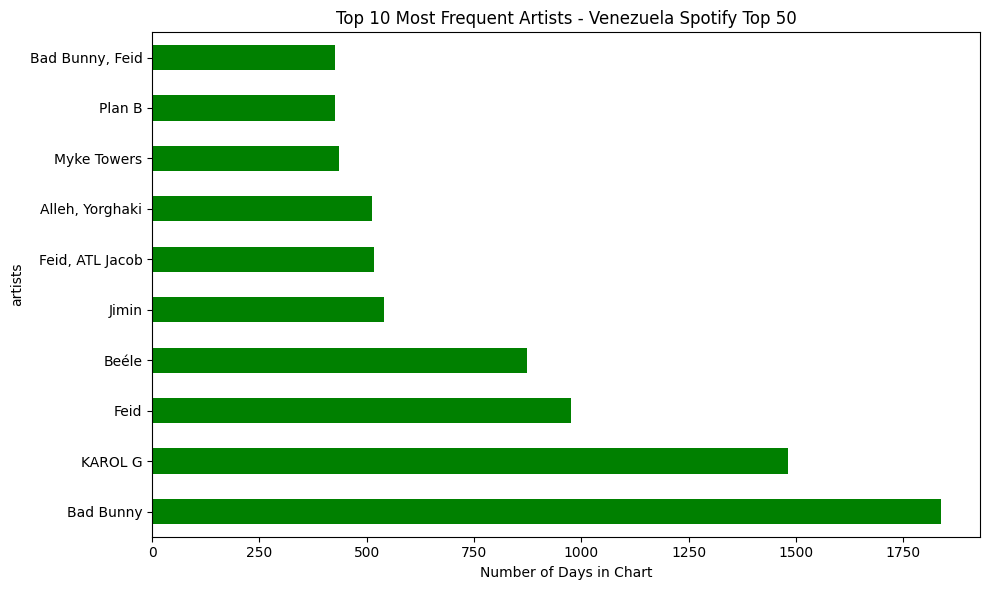

In [15]:
# Chart 1: Top 10 artists by days in chart
top_artists.plot(kind='barh', figsize=(10,6), color='green')
plt.title('Top 10 Most Frequent Artists - Venezuela Spotify Top 50')
plt.xlabel('Number of Days in Chart')
plt.tight_layout()
plt.show()

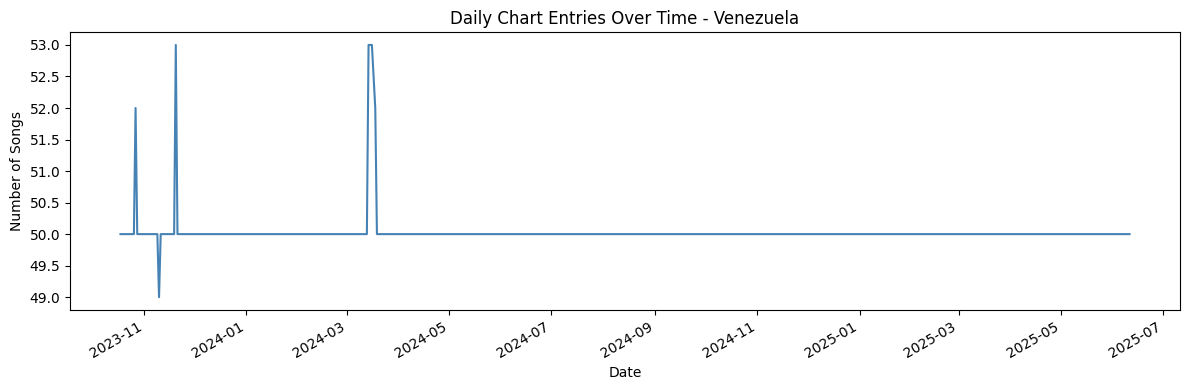

In [16]:
# Chart 2: Songs over time
daily = df_clean.groupby('snapshot_date')['name'].count()
daily.plot(figsize=(12,4), color='steelblue')
plt.title('Daily Chart Entries Over Time - Venezuela')
plt.xlabel('Date')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

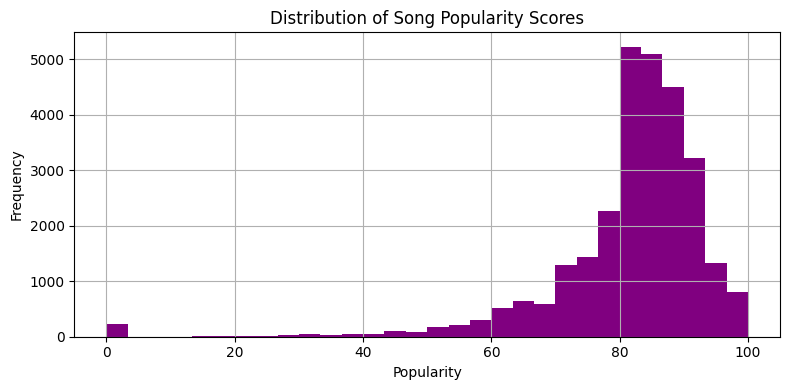

In [17]:
# Chart 3: Distribution of popularity scores
df_clean['popularity'].hist(bins=30, figsize=(8,4), color='purple')
plt.title('Distribution of Song Popularity Scores')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

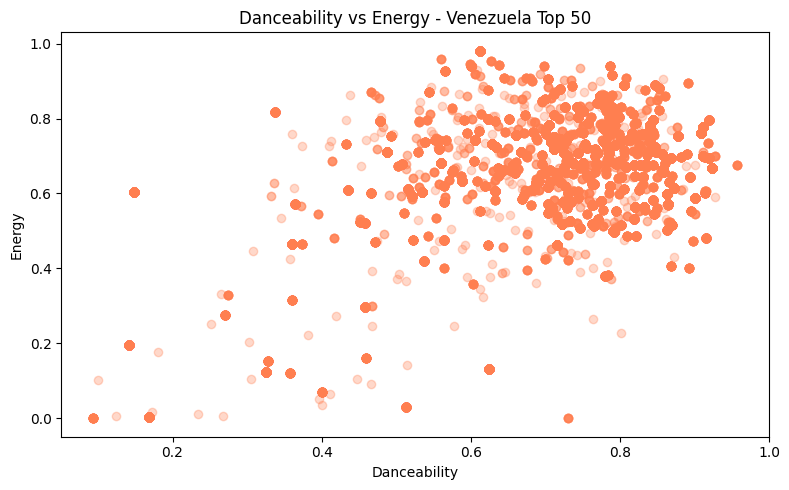

In [18]:
# Chart 4: Danceability vs Energy scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df_clean['danceability'], df_clean['energy'], alpha=0.3, color='coral')
plt.title('Danceability vs Energy - Venezuela Top 50')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.tight_layout()
plt.show()

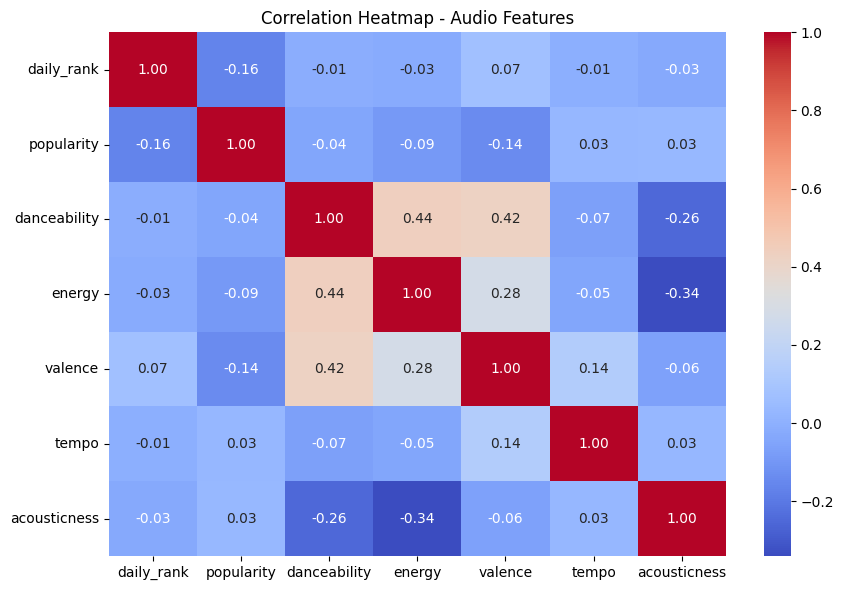

In [19]:
# Chart 5: Correlation heatmap
import seaborn as sns

corr = df_clean[['daily_rank','popularity','danceability','energy','valence','tempo','acousticness']].corr()
plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Audio Features')
plt.tight_layout()
plt.show()

# Section 8: Findings and Observations

1. Bad Bunny dominates the Venezuela Spotify charts with 1,837 days in the Top 50 — nearly double KAROL G in second place.
2. Feid appears both solo and in collaborations, making him one of the most consistent presences in the chart.
3. The dataset spans from 2023 to 2024, with consistent daily coverage of 50 songs.
4. Most songs have high danceability scores (above 0.6), reflecting Venezuela's preference for rhythmic, danceable music.
5. A small number of rows had missing song names or artist data and were removed during cleaning.
6. Popularity scores vary widely, suggesting that chart position alone does not determine overall Spotify popularity.